In [23]:
import numpy as np
import matplotlib.pyplot as plt
import ot

In [24]:
# Problem size
n1 = 25
n2 = 50

# Generate random data
np.random.seed(0)
a = ot.utils.unif(n1)  # Weights of points in the source domain
b = ot.utils.unif(n2)  # Weights of points in the target domain

x1 = np.random.randn(n1, 2)  # Source points
x1 /= np.sqrt(np.sum(x1 ** 2, axis=1, keepdims=True)) / 2       # Normalize to lie on the unit circle

x2 = np.random.randn(n2, 2)  # Target points
x2 /= np.sqrt(np.sum(x2 ** 2, axis=1, keepdims=True)) / 4       # Normalize to lie on the unit circle

### Large scale Sinkhorn

When having samples with a large number of points, the Sinkhorn algorithm can be implemented in a Lazy version which is more memory efficient and avoids the computation of the $n \times m$ cost matrix.

POT provides two implementation of the lazy Sinkhorn algorithm that return their results in a lazy form of type `ot.utils.LazyTensor`. This object can be used to compute the loss or the OT plan in a lazy way or to recover its values in a dense form.

In [25]:
# Solve the Sinkhorn problem in a lazy way
sol = ot.solve_sample(x1, x2, a, b, reg=0.1, lazy=True)

# Solve the Sinkhorn in a lazy way with geomloss
# Note: requires pykeops to be installed (pip install pykeops)
# sol_geo = ot.solve_sample(x1, x2, a, b, reg=0.1, method="geomloss", lazy=True)

# Get the OT lazy plan and loss
P_sink_lazy = sol.lazy_plan

# Recover values for lazy plan
P12 = P_sink_lazy[1, 2]
P1dots = P_sink_lazy[1, :]
# Convert to dense matrix !! Warning this can be memory consuming
P_sink_lazy_dense = P_sink_lazy[:]

print(P_sink_lazy)
print(P_sink_lazy_dense)

LazyTensor(shape=(25, 50),attributes=(X_a,X_b,f,g,metric,reg))
[[2.91155879e-076 5.73560742e-099 1.66175576e-023 ... 5.22426087e-005
  6.11640672e-048 1.11390477e-108]
 [1.79641531e-050 1.74899080e-157 1.00047187e-002 ... 2.12640501e-054
  2.67691044e-015 5.16187064e-117]
 [2.30859215e-075 9.57437864e-039 1.67975181e-056 ... 3.20858964e-014
  8.77634178e-067 5.40163335e-073]
 ...
 [2.28272165e-017 4.42844943e-023 9.31303046e-104 ... 5.68588829e-167
  2.57984957e-046 1.49333891e-002]
 [4.57249313e-005 8.80347651e-122 1.32847445e-047 ... 1.05230211e-168
  7.09502814e-005 1.04588083e-049]
 [3.72320838e-006 6.64810333e-068 1.41231706e-084 ... 1.05439570e-186
  4.82106338e-026 2.83043139e-017]]


/home/ansible/miniconda3/lib/python3.13/site-packages/ot/bregman/_empirical.py:259: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


the first example shows how to solve the Sinkhorn problem in a lazy way with the default POT implementation. The second example shows how to solve the Sinkhorn problem in a lazy way with the PyKeops/Geomloss implementation that provides a very efficient way to solve large scale problems on low dimensionality samples.

### Factored and Low rank OT

The Sinkhorn algorithm can be implemented in a low rank version that approximates the OT plan with a low rank matrix. This can be useful to accelerate the computation of the OT plan for large scale problems. A similar non-regularized version of low rank factorization is also available.

In [26]:
# Solve the Factored OT problem (use lazy=True for large scale)
P_fact = ot.solve_sample(x1, x2, a, b, method="factored", rank=15).plan

P_lowrank = ot.solve_sample(x1, x2, a, b, reg=0.1, method="lowrank", rank=10).plan

print(P_fact)
print(P_lowrank)

[[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 1.33333333e-03
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.20000000e-02 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 ...
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 1.20000000e-02]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [4.16333634e-17 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]]
[[6.47301541e-10 1.55894306e-10 4.38838511e-04 ... 4.07549380e-03
  1.88970280e-06 2.71081968e-14]
 [1.12633059e-06 9.41673123e-17 4.49360869e-03 ... 2.36440756e-06
  7.25666701e-04 2.95585152e-12]
 [1.40382838e-11 1.27650402e-04 4.05158920e-08 ... 1.24459032e-04
  1.84300982e-10 3.44490385e-09]
 ...
 [2.45118658e-04 9.06336765e-04 1.35749221e-11 ... 6.95872674e-17
  5.34593820e-06 5.55119290e-03]

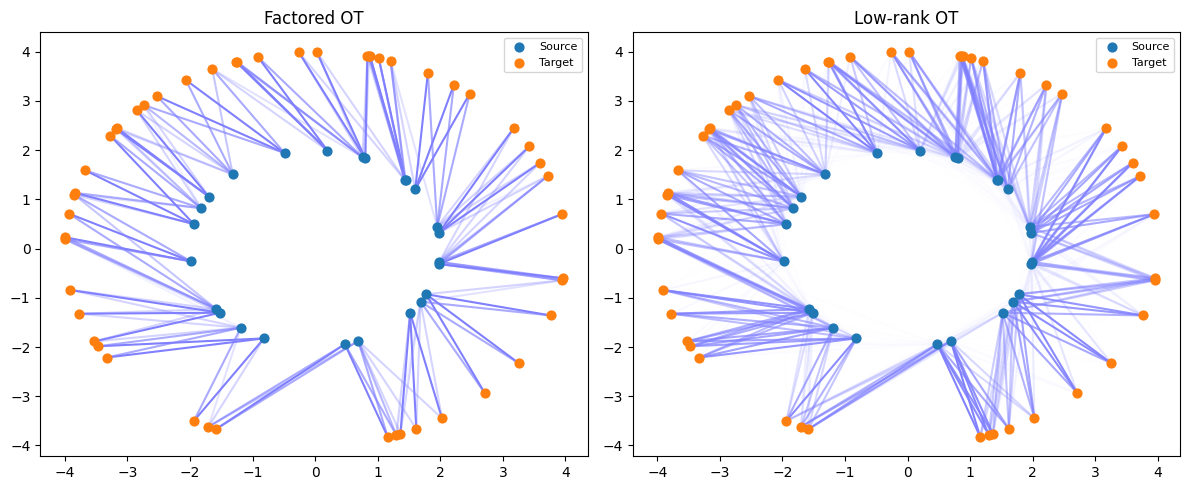

In [27]:
def plot_transport(ax, x1, x2, P, title):
    max_P = P.max()
    for i in range(len(x1)):
        for j in range(len(x2)):
            if P[i, j] > 0:
                ax.plot([x1[i, 0], x2[j, 0]], [x1[i, 1], x2[j, 1]],
                        color=[0.5, 0.5, 1], alpha=float(P[i, j] / max_P))
    ax.scatter(*x1.T, s=40, zorder=3, label="Source")
    ax.scatter(*x2.T, s=40, zorder=3, label="Target")
    ax.set_title(title)
    ax.legend(loc="upper right", fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_transport(axes[0], x1, x2, P_fact, "Factored OT")
plot_transport(axes[1], x1, x2, P_lowrank, "Low-rank OT")

plt.tight_layout()
plt.show()

### Gaussian OT with Bures-Wasserstein

The Gaussian Wasserstein or Bures-Wasserstein distance is the Wasserstein distance between Gaussian distributions. It can be used as an approximation of the Wasserstein distance between empirical distributions by estimating the covariance matrices of the samples.

In [28]:
# Compute the Bures-Wasserstein distance
loss = ot.solve_sample(x1, x2, a, b).value
bw_value = ot.solve_sample(x1, x2, a, b, method="gaussian").value

print(f"Exact OT loss = {loss:1.3f}")
print(f"Bures-Wasserstein distance = {bw_value:1.3f}")

Exact OT loss = 5.292
Bures-Wasserstein distance = 4.558
